# Segmented map with a customized heat map

## Table of Contents

1. [Introduction](#1--introduction)
2. [Setup and Imports](#2--setup-and-imports)
3. [Data Loading and Preprocessing](#3--data-loading-and-preprocessing)
4. [Data Augmentation](#4--data-augmentation)
5. [U-Net Model Definition](#5--u-net-model-definition)
6. [Training](#6--training)
7. [Evaluation](#7--evaluation)
8. [Visualization](#8--visualization)

## 1- Introduction
---

## 2- Setup and Imports
---

In [5]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 3- Data Loading and Preprocessing 
---

### *Discover the Image first*

Detected 1 mainland regions.


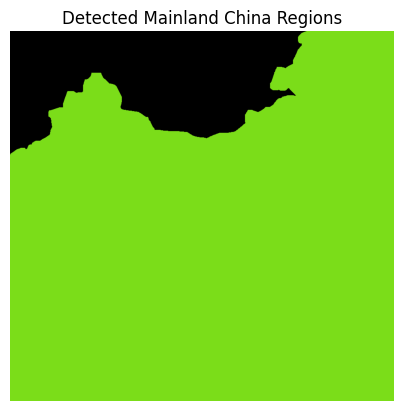

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load image
img = cv2.imread('data/china_map.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 2: Edge detection (Canny)
edges = cv2.Canny(gray, 50, 150)

# Step 3: Dilate to connect lines and fill shapes
kernel = np.ones((5, 5), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=2)

# Step 4: Fill closed areas (invert and flood fill)
filled = dilated.copy()
h, w = filled.shape
mask = np.zeros((h+2, w+2), np.uint8)
cv2.floodFill(filled, mask, (0, 0), 255)
filled_inv = cv2.bitwise_not(filled)
filled_combined = cv2.bitwise_or(dilated, filled_inv)

# Step 5: Find contours
contours, _ = cv2.findContours(
    filled_combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter out small islands (area threshold)
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 1000]

print(f"Detected {len(filtered_contours)} mainland regions.")

# Step 6: Visualize result
segmentation = np.zeros_like(gray)
for idx, cnt in enumerate(filtered_contours):
    cv2.drawContours(segmentation, [cnt], -1, (idx + 1), thickness=cv2.FILLED)

colored_map = np.zeros((h, w, 3), dtype=np.uint8)
colors = np.random.randint(0, 255, (len(filtered_contours) + 1, 3))
for i in range(1, len(filtered_contours) + 1):
    colored_map[segmentation == i] = colors[i]

plt.imshow(colored_map)
plt.title("Detected Mainland China Regions")
plt.axis("off")
plt.show()

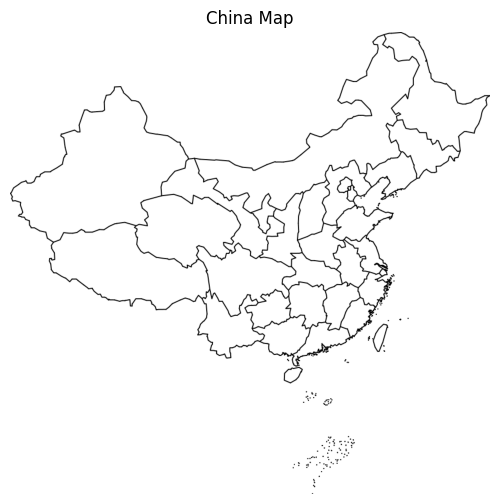

In [2]:
# Load the image
img = cv2.imread('data/china_map.png')

# Convert from BGR (OpenCV default) to RGB for correct display
china_map_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8, 6))
plt.imshow(china_map_rgb)
plt.title("China Map")
plt.axis("off")
plt.show()

In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Threshold to binary (provinces are white)
# Invert: contours are black on white now
_, thresh = cv2.threshold(gray, 254, 255, cv2.THRESH_BINARY_INV)

# Optional: Morph close to ensure small gaps are filled
kernel = np.ones((3, 3), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

In [7]:
# Get contours
contours, _ = cv2.findContours(
    thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"Detected {len(contours)} regions (provinces).")

Detected 61 regions (provinces).


In [8]:
h, w = thresh.shape
labeled_map = np.zeros((h, w), dtype=np.int32)

for idx, contour in enumerate(contours):
    cv2.drawContours(labeled_map, [contour], -1,
                     (idx + 1), thickness=cv2.FILLED)

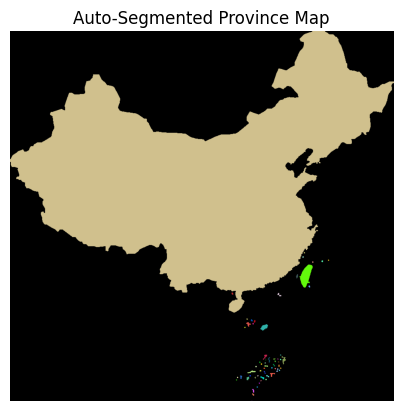

In [9]:
colored_map = np.zeros((h, w, 3), dtype=np.uint8)
colors = np.random.randint(0, 255, (len(contours) + 1, 3))

for idx in range(1, len(contours) + 1):
    colored_map[labeled_map == idx] = colors[idx]

plt.imshow(colored_map)
plt.title("Auto-Segmented Province Map")
plt.axis("off")
plt.show()

### *Preprocess the Image*

- **Convert to grayscale**

In [3]:
# Convert to grayscale and threshold to isolate provinces (white regions)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 254, 255, cv2.THRESH_BINARY)

- **find contours of provinces**

In [4]:
# Find contours of provinces (using RETR_EXTERNAL to get only outer contours)
contours, _ = cv2.findContours(
    thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

### *Preprocess the CSV data*

In [13]:
# Read the CSV data
df = pd.read_csv('data/china_map_values.csv')
provinces = df['Provinces'].tolist()
values = df['Mb 2005'].tolist()

In [14]:

# Check if the number of contours matches the number of provinces
if len(contours) != len(provinces):
    raise ValueError(
        f"Number of contours ({len(contours)}) does not match number of provinces ({len(provinces)})")

ValueError: Number of contours (44) does not match number of provinces (31)